# **수정 사항**
- Threshold 산출 코드 변경

# **1. 드라이브 연결**

In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

Mounted at /content/drive


# **2. 전처리 및 데이터셋 설정**

- 실험 별로 나누어서 진행

In [2]:
# ==========================================
# 1. 라이브러리 및 환경 설정 (필수)
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix, f1_score
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import MinMaxScaler
import warnings


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 2. 데이터 로드
# ==========================================
file_path = "/content/drive/MyDrive/ASK_2026_FDC/Dataset/MACHINE_Data.xlsx"

if os.path.exists(file_path):
    print(f"Loading data from: {file_path}")
    if file_path.endswith('.xlsx'):
        df = pd.read_excel(file_path)
    else:
        df = pd.read_csv(file_path)
else:
    print("파일을 찾을 수 없습니다. 경로를 확인해주세요.")
    df = pd.DataFrame()

# 센서 컬럼 정의
sensor_cols = [
    'BCl3 Flow', 'Cl2 Flow', 'RF Btm Pwr', 'RF Btm Rfl Pwr', 'Endpt A',
    'He Press', 'Pressure', 'RF Tuner', 'RF Load', 'RF Phase Err',
    'RF Pwr', 'RF Impedance', 'TCP Tuner', 'TCP Phase Err',
    'TCP Impedance', 'TCP Top Pwr', 'TCP Rfl Pwr', 'TCP Load', 'Vat Valve'
]

# ==========================================
# 3. 데이터 전처리 함수
# ==========================================
"""
    Wafer_ID 별로 슬라이딩 윈도우를 적용하고,
    각 윈도우가 어떤 Wafer에 속하는지 ID 리스트를 함께 반환합니다.
"""
def create_sequences_with_ids(df_target, wafer_col, sensor_cols, seq_len, scaler=None, is_train=True):

    # 1. 데이터 추출
    data_values = df_target[sensor_cols].values

    # 2. 스케일링 (Train 통계로만 Scale)
    if is_train:
        if scaler is None:
            scaler = MinMaxScaler()
        data_scaled = scaler.fit_transform(data_values)
    else:
        if scaler is None:
            raise ValueError("Test mode requires a fitted scaler from training data.")
        data_scaled = scaler.transform(data_values)

    # 스케일링된 데이터를 다시 DataFrame으로 매핑 (ID 그룹핑 용도)
    df_scaled = pd.DataFrame(data_scaled, columns=sensor_cols, index=df_target.index)
    df_scaled[wafer_col] = df_target[wafer_col].values

    all_sequences = []
    all_wafer_ids = [] # [NEW] 각 윈도우의 소스 Wafer ID를 저장할 리스트

    unique_wafers = df_scaled[wafer_col].unique()

    for wafer in unique_wafers:
        # 특정 Wafer 데이터 추출
        wafer_data = df_scaled[df_scaled[wafer_col] == wafer][sensor_cols].values

        # 데이터 길이가 윈도우보다 작으면 스킵
        if len(wafer_data) < seq_len:
            continue

        # 슬라이딩 윈도우 생성
        for i in range(len(wafer_data) - seq_len + 1):
            window = wafer_data[i : i + seq_len]

            all_sequences.append(window)
            all_wafer_ids.append(wafer) # [NEW] 현재 윈도우의 Wafer ID 저장

    if len(all_sequences) == 0:
        return np.array([]), np.array([]), scaler

    return np.array(all_sequences), np.array(all_wafer_ids), scaler

# ==========================================
# 4. 데이터셋 구성 및 저장
# ==========================================
experiments = ['l29', 'l31', 'l33']
datasets = {}
SEQ_LEN = 32

# 학습 데이터 비율 설정
TRAIN_RATIO = 0.6

print(f"\n--- Preprocessing Data (Train Ratio: {TRAIN_RATIO*100}%) ---")

for exp_id in experiments:
    print(f"\nProcessing Experiment: {exp_id}")

    # 1. 실험 데이터 필터링
    exp_df = df[df['Wafer_ID'].str.contains(exp_id, case=False, na=False)]
    if exp_df.empty:
        continue

    # 2. Train / Test Split (Wafer ID 기준)
    normal_wafer_ids = exp_df[exp_df['Label'] == 'Normal']['Wafer_ID'].unique()
    fault_wafer_ids = exp_df[exp_df['Label'] == 'Fault']['Wafer_ID'].unique()

    # [수정] 비율 적용 (Normal Wafer만 분할)
    n_train = int(len(normal_wafer_ids) * TRAIN_RATIO)

    train_ids = normal_wafer_ids[:n_train]
    test_norm_ids = normal_wafer_ids[n_train:]

    # ID 기반 데이터프레임 분할
    train_df = exp_df[exp_df['Wafer_ID'].isin(train_ids)]
    test_norm_df = exp_df[exp_df['Wafer_ID'].isin(test_norm_ids)]
    test_fault_df = exp_df[exp_df['Wafer_ID'].isin(fault_wafer_ids)]

    print(f"  - Total Normal: {len(normal_wafer_ids)}")
    print(f"  -> Train Normal : {len(train_ids)} ({TRAIN_RATIO*100:.0f}%)")
    print(f"  -> Test Normal  : {len(test_norm_ids)} ({(1-TRAIN_RATIO)*100:.0f}%)")
    print(f"  -> Test Fault   : {len(fault_wafer_ids)} (100%)")

    # 3. 시퀀스 생성 (X, Wafer_ID 반환)
    # (1) Train: Scaler 학습 (Fit)
    X_train, y_train_ids, scaler = create_sequences_with_ids(
        train_df, 'Wafer_ID', sensor_cols, SEQ_LEN, scaler=None, is_train=True
    )

    # (2) Test Normal: Scaler 적용 (Transform)
    X_test_norm, y_test_norm_ids, _ = create_sequences_with_ids(
        test_norm_df, 'Wafer_ID', sensor_cols, SEQ_LEN, scaler=scaler, is_train=False
    )

    # (3) Test Fault: Scaler 적용 (Transform)
    if not test_fault_df.empty:
        X_test_fault, y_test_fault_ids, _ = create_sequences_with_ids(
            test_fault_df, 'Wafer_ID', sensor_cols, SEQ_LEN, scaler=scaler, is_train=False
        )
    else:
        X_test_fault, y_test_fault_ids = np.array([]), np.array([])

    # 4. Dictionary에 저장
    datasets[exp_id] = {
        'X_train': X_train,
        'X_test_norm': X_test_norm,
        'X_test_fault': X_test_fault,
        'ids_train': y_train_ids,
        'ids_test_norm': y_test_norm_ids,
        'ids_test_fault': y_test_fault_ids,
        'scaler': scaler
    }

print("\n✅ Data preprocessing with new ratio completed.")

Using device: cuda
Loading data from: /content/drive/MyDrive/ASK_2026_FDC/Dataset/MACHINE_Data.xlsx

--- Preprocessing Data (Train Ratio: 60.0%) ---

Processing Experiment: l29
  - Total Normal: 34
  -> Train Normal : 20 (60%)
  -> Test Normal  : 14 (40%)
  -> Test Fault   : 9 (100%)

Processing Experiment: l31
  - Total Normal: 37
  -> Train Normal : 22 (60%)
  -> Test Normal  : 15 (40%)
  -> Test Fault   : 6 (100%)

Processing Experiment: l33
  - Total Normal: 37
  -> Train Normal : 22 (60%)
  -> Test Normal  : 15 (40%)
  -> Test Fault   : 6 (100%)

✅ Data preprocessing with new ratio completed.


# **3. 공통 함수 정의**

In [3]:
# ==========================================
# 3. 공통 함수
# ==========================================
def get_data_loaders(exp_id, datasets_dict, batch_size=32):
    print(f"\n📊 [Data Setup] Experiment: {exp_id}")
    data = datasets_dict[exp_id]

    # 데이터 추출
    X_train = data['X_train']
    X_test_norm = data['X_test_norm']
    ids_test_norm = data['ids_test_norm']
    X_test_fault = data['X_test_fault']
    ids_test_fault = data['ids_test_fault']

    # Tensor 변환
    train_tensor = torch.FloatTensor(X_train)
    test_norm_tensor = torch.FloatTensor(X_test_norm)

    if len(X_test_fault) > 0:
        test_fault_tensor = torch.FloatTensor(X_test_fault)
    else:
        test_fault_tensor = torch.FloatTensor([])

    # DataLoader (Train only)
    train_loader = DataLoader(TensorDataset(train_tensor), batch_size=batch_size, shuffle=True)

    return train_loader, (test_norm_tensor, ids_test_norm), (test_fault_tensor, ids_test_fault)

def aggregate_wafer_scores(window_scores, wafer_ids, method='max'):
    # DataFrame핑하여 GroupBy 연산
    df_temp = pd.DataFrame({'Wafer_ID': wafer_ids, 'Score': window_scores})

    if method == 'max':
        grouped = df_temp.groupby('Wafer_ID')['Score'].max()
    else:
        grouped = df_temp.groupby('Wafer_ID')['Score'].mean()

    return grouped.index.values, grouped.values

def visualize_results(model_name, exp_id, scores, labels, threshold):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    plt.suptitle(f"[{exp_id}] {model_name} Performance (Wafer-Level)", fontsize=16, fontweight='bold')

    # Confusion Matrix
    preds = (scores > threshold).astype(int)
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
                xticklabels=['Normal', 'Fault'], yticklabels=['Normal', 'Fault'])
    axes[0].set_title("Confusion Matrix")

    # Scatter Plot (Wafer Scores)
    normal_idx = np.where(labels == 0)[0]
    fault_idx = np.where(labels == 1)[0]

    axes[1].scatter(normal_idx, scores[normal_idx], color='blue', label='Normal', alpha=0.6, s=20)
    axes[1].scatter(fault_idx, scores[fault_idx], color='red', label='Fault', alpha=0.6, s=20)
    axes[1].axhline(y=threshold, color='green', linestyle='--', label='Threshold')
    axes[1].set_title("Wafer Anomaly Scores")
    axes[1].legend()

    # ROC Curve
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)
    axes[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
    axes[2].plot([0, 1], [0, 1], color='navy', linestyle='--')
    axes[2].set_title("ROC Curve")
    axes[2].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

def evaluate_performance_fixed_threshold(model_name, exp_id, scores, labels, threshold):
    # 1. 고정된 임계값을 기준으로 이상 여부 판별 (크면 1: Fault, 작으면 0: Normal)
    preds = (scores > threshold).astype(int)

    # 2. F1-Score 계산 (더 이상 최적의 값을 찾지 않음)
    f1 = f1_score(labels, preds)

    # 3. AUROC 계산 (AUC는 임계값과 무관하게 모델의 분류 잠재력을 보여줌)
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)

    print(f"\n📌 [{model_name} - {exp_id}] Wafer-Level Summary (Unsupervised)")
    print(f"   - AUROC          : {roc_auc:.4f}")
    print(f"   - F1-Score       : {f1:.4f} (at Fixed Threshold: {threshold:.6f})")

    # 시각화 함수 호출
    visualize_results(model_name, exp_id, scores, labels, threshold)

    return roc_auc, f1

# **4. 모델 구현 및 학습**

In [4]:
# ==========================================
# [Cell 2] 실험별 모델 학습 및 비지도 임계값 산출
# ==========================================
target_experiments = ['l29', 'l31', 'l33']

if 'trained_artifacts' not in globals():
    trained_artifacts = {}


# 1. 공통 하이퍼파라미터
BATCH_SIZE = 32
NUM_EPOCHS = 50
LEARNING_RATE = 0.001
SIGMA_MULTIPLIER = 6

## **1D-CNN AE**

In [5]:
import torch
import torch.nn as nn

class CNN1D_AE(nn.Module):
    def __init__(self, num_sensors=19, seq_len=32, latent_dim=8):
        super(CNN1D_AE, self).__init__()

        # 논문 권장사항: 작은 Kernel Size 선호
        # 모델 경량화 및 seq_len=32를 고려하여 kernel_size=3, stride=2 사용

        # ---------------------------
        # Encoder (차원 축소)
        # ---------------------------
        self.encoder = nn.Sequential(
            # Input: (Batch, 19, 32) -> Output: (Batch, 32, 16)
            nn.Conv1d(in_channels=num_sensors, out_channels=32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(), # 각 레이어마다 ReLU 적용

            # Input: (Batch, 32, 16) -> Output: (Batch, 16, 8)
            nn.Conv1d(in_channels=32, out_channels=16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),

            # Input: (Batch, 16, 8) -> Output: (Batch, latent_dim, 4)
            nn.Conv1d(in_channels=16, out_channels=latent_dim, kernel_size=3, stride=2, padding=1),
            nn.ReLU()
        )

        # ---------------------------
        # Decoder (대칭적 복원 )
        # ---------------------------
        self.decoder = nn.Sequential(
            # Input: (Batch, latent_dim, 4) -> Output: (Batch, 16, 8)
            nn.ConvTranspose1d(in_channels=latent_dim, out_channels=16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),

            # Input: (Batch, 16, 8) -> Output: (Batch, 32, 16)
            nn.ConvTranspose1d(in_channels=16, out_channels=32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),

            # Input: (Batch, 32, 16) -> Output: (Batch, 19, 32)
            # 마지막 레이어는 입력 데이터의 스케일(MinMax, 0~1)에 맞춰 Sigmoid를 적용하거나 생략할 수 있습니다.
            nn.ConvTranspose1d(in_channels=32, out_channels=num_sensors, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # 🚨 중요: 이전 단계에서 언급했던 차원 변환 (Batch, Seq_Len, Sensors) -> (Batch, Sensors, Seq_Len)
        x = x.transpose(1, 2)

        latent = self.encoder(x)
        reconstructed = self.decoder(latent)

        # 출력 시 다시 원래 형태로 복구 (Batch, Seq_Len, Sensors)
        return reconstructed.transpose(1, 2)



import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

def train_cnn1d(model, train_loader, optimizer, epoch, device):
    model.train()
    total_loss = 0
    criterion = nn.L1Loss() # MAE Loss

    for (data,) in train_loader:
        data = data.to(device)
        optimizer.zero_grad()

        # AE는 자기 자신을 타겟으로 복원
        output = model(data)
        loss = criterion(output, data)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    if (epoch + 1) % 10 == 0: # 에포크가 많으므로 10단위 출력
        print(f"Epoch [{epoch+1}] Loss: {avg_loss:.4f}")
    return avg_loss

def cnn1d_calculate_window_scores(model, data_tensor, device, batch_size=32):
    model.eval()
    all_scores = []
    criterion = nn.L1Loss(reduction='none')

    dataset = TensorDataset(data_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    with torch.no_grad():
        for (data,) in loader:
            data = data.to(device)
            output = model(data)

            # Element-wise MAE Loss: (Batch, Seq_Len, Num_Sensors)
            loss_element = criterion(output, data)

            # [논문 반영] Localised Reconstruction Error (LRE)
            # 1. 채널별(byChannel) 시간축 평균 에러 계산 -> (Batch, Num_Sensors)
            channel_errors = loss_element.mean(dim=1)
            # 2. 센서 중 가장 높은 오차값을 윈도우 스코어로 사용 -> (Batch)
            score_window, _ = channel_errors.max(dim=1)

            all_scores.extend(score_window.cpu().numpy())

    return np.array(all_scores)

In [6]:
# ==========================================
# 1D-CNN AE 모델 학습 (Phase 1)
# ==========================================
m_name = "1D-CNN AE"
cnn1d_config = {
    "latent_dim": 8
}

if m_name not in trained_artifacts:
    trained_artifacts[m_name] = {}

print(f"\n🚀 Phase 1: Training [{m_name}] on Experiments: {target_experiments}")

for exp_id in target_experiments:
    if exp_id not in datasets:
        print(f"Skipping {exp_id}: Dataset not found.")
        continue

    print(f"\n" + "-"*40)
    print(f" 🏭 Training on Experiment: {exp_id}")
    print("-" * 40)

    train_loader, _, _ = get_data_loaders(exp_id, datasets, BATCH_SIZE)
    num_sensors = train_loader.dataset.tensors[0].shape[2]
    seq_len_input = train_loader.dataset.tensors[0].shape[1]

    # 모델 객체 초기화 (Next-token이 아니므로 seq_len_input 길이 유지)
    model = CNN1D_AE(
        num_sensors=num_sensors,
        seq_len=seq_len_input,
        latent_dim=cnn1d_config["latent_dim"]
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    for epoch in range(NUM_EPOCHS):
        train_cnn1d(model, train_loader, optimizer, epoch, device)

    print(f"Calculating Train Scores for Thresholding")
    train_tensor = train_loader.dataset.tensors[0]
    train_window_scores = cnn1d_calculate_window_scores(model, train_tensor, device, BATCH_SIZE)

    ids_train = datasets[exp_id]['ids_train']
    _, train_wafer_scores = aggregate_wafer_scores(train_window_scores, ids_train, method='max')

    train_mean = np.mean(train_wafer_scores)
    train_std = np.std(train_wafer_scores)
    fixed_threshold = train_mean + (SIGMA_MULTIPLIER * train_std)

    print(f"   * Train Score Mean: {train_mean:.4f}, Std: {train_std:.4f}")
    print(f"   * Fixed {SIGMA_MULTIPLIER}-Sigma Threshold: {fixed_threshold:.4f}")

    trained_artifacts[m_name][exp_id] = {
        'model': model,
        'threshold': fixed_threshold,
        'config': cnn1d_config
    }

print(f"\n✅ [{m_name}] successfully trained and saved for all experiments.")


🚀 Phase 1: Training [1D-CNN AE] on Experiments: ['l29', 'l31', 'l33']

----------------------------------------
 🏭 Training on Experiment: l29
----------------------------------------

📊 [Data Setup] Experiment: l29
Epoch [10] Loss: 0.1060
Epoch [20] Loss: 0.0845
Epoch [30] Loss: 0.0826
Epoch [40] Loss: 0.0816
Epoch [50] Loss: 0.0811
Calculating Train Scores for Thresholding
   * Train Score Mean: 0.3313, Std: 0.0627
   * Fixed 6-Sigma Threshold: 0.7074

----------------------------------------
 🏭 Training on Experiment: l31
----------------------------------------

📊 [Data Setup] Experiment: l31
Epoch [10] Loss: 0.1034
Epoch [20] Loss: 0.0825
Epoch [30] Loss: 0.0805
Epoch [40] Loss: 0.0798
Epoch [50] Loss: 0.0791
Calculating Train Scores for Thresholding
   * Train Score Mean: 0.2433, Std: 0.0266
   * Fixed 6-Sigma Threshold: 0.4029

----------------------------------------
 🏭 Training on Experiment: l33
----------------------------------------

📊 [Data Setup] Experiment: l33
Epoch [

## **LSTM-AE**

## **LOF-IF**

## **TranAD**

## **VTimesNet**

In [7]:
import torch
import torch.nn as nn
import torch.fft
import torch.nn.functional as F

class DCM(nn.Module):
    """
    Dilated Convolutional Module (2D 기반 다중 스케일 특징 추출)
    논문: 팽창률(Dilation rate) 2, 커널 크기 {1,2,3,4,5,6} 병렬 적용 [cite: 127]
    """
    def __init__(self, in_channels):
        super(DCM, self).__init__()
        self.convs = nn.ModuleList([
            nn.Conv2d(in_channels, in_channels, kernel_size=k, padding='same', dilation=2)
            for k in range(1, 7)
        ])

    def forward(self, x):
        # 다중 스케일 특징 F1 ~ F6 반환
        return [conv(x) for conv in self.convs]

class GLGM(nn.Module):
    """
    Global-Local-Global Fusion Module
    논문: Global-Local 경로와 Local-Global 경로를 통한 양방향 정보 융합 [cite: 170, 174, 179]
    """
    def __init__(self, channels):
        super(GLGM, self).__init__()
        # 논문 구조상 단순화를 위해 1x1 Conv로 스케일 융합을 모사 (실제 구현 시 해상도 조절 가능)
        self.fusion_conv = nn.Conv2d(channels * 6, channels, kernel_size=3, padding=1)

    def forward(self, features):
        # 6개의 다중 스케일 특징(F1~F6)을 양방향 융합 (단순화된 병합 구조)
        concat_features = torch.cat(features, dim=1)
        out = self.fusion_conv(concat_features)
        return out

class CBAM(nn.Module):
    """
    Convolutional Block Attention Module
    논문: 채널 어텐션과 공간 어텐션을 순차적으로 적용 [cite: 184, 185, 190]
    """
    def __init__(self, channels):
        super(CBAM, self).__init__()
        # Channel Attention [cite: 186, 187, 188]
        self.ca_mlp = nn.Sequential(
            nn.Conv2d(channels, channels // 2, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(channels // 2, channels, 1, bias=False)
        )
        self.ca_sigmoid = nn.Sigmoid()

        # Spatial Attention [cite: 191, 192]
        self.sa_conv = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)
        self.sa_sigmoid = nn.Sigmoid()

    def forward(self, x):
        # 1. Channel Attention
        avg_out = self.ca_mlp(F.adaptive_avg_pool2d(x, 1))
        max_out = self.ca_mlp(F.adaptive_max_pool2d(x, 1))
        ca_weight = self.ca_sigmoid(avg_out + max_out)
        x = x * ca_weight

        # 2. Spatial Attention
        avg_pool = torch.mean(x, dim=1, keepdim=True)
        max_pool, _ = torch.max(x, dim=1, keepdim=True)
        sa_weight = self.sa_sigmoid(self.sa_conv(torch.cat([avg_pool, max_pool], dim=1)))
        x = x * sa_weight
        return x

class TimesPlusBlock(nn.Module):
    """
    V-TimesNet의 핵심 블록: 1D -> 2D 변환 -> 비전 모듈(DCM, GLGM, CBAM) -> 1D 복원 [cite: 96, 116, 119]
    """
    def __init__(self, d_model, k=3):
        super(TimesPlusBlock, self).__init__()
        self.k = k
        self.dcm = DCM(d_model)
        self.glgm = GLGM(d_model)
        self.cbam = CBAM(d_model)

    def forward(self, x):
        B, C, T = x.size()
        x_fft = torch.fft.rfft(x, dim=-1)
        ampls = torch.abs(x_fft)

        avg_ampls = ampls.mean(dim=0).mean(dim=0)
        topk_ampls, topk_indices = torch.topk(avg_ampls, k=self.k)

        res = []
        for idx in topk_indices:
            freq = idx.item()
            period = 1 if freq == 0 else T // freq

            pad_len = 0 if T % period == 0 else period - (T % period)
            x_pad = F.pad(x, (0, pad_len)) if pad_len > 0 else x

            # 1. 1D to 2D Reshape [cite: 84]
            x_2d = x_pad.view(B, C, -1, period)

            # 2. Vision Modules (DCM -> GLGM -> CBAM) [cite: 96]
            dcm_out = self.dcm(x_2d)
            glgm_out = self.glgm(dcm_out)
            out_2d = self.cbam(glgm_out)

            # 3. 2D to 1D Reshape [cite: 96]
            out_1d = out_2d.view(B, C, -1)
            if pad_len > 0:
                out_1d = out_1d[..., :-pad_len]
            res.append(out_1d)

        res = torch.stack(res, dim=-1)
        weights = torch.softmax(topk_ampls, dim=-1).unsqueeze(0).unsqueeze(0).unsqueeze(0)
        out = torch.sum(res * weights.to(x.device), dim=-1)

        return out + x # Residual Connection [cite: 79]

class VTimesNet(nn.Module):
    def __init__(self, seq_len, n_features, d_model=4, k=3, num_layers=3, fcn_dim=16):
        super(VTimesNet, self).__init__()
        self.embedding = nn.Linear(n_features, d_model)

        # P개의 TimesPlus 블록 적층 (논문 기준 3개) [cite: 73, 266]
        self.layers = nn.ModuleList([TimesPlusBlock(d_model, k=k) for _ in range(num_layers)])

        # Reconstruction Head: FCN dimension 반영 [cite: 379, 380]
        self.projection = nn.Sequential(
            nn.Linear(d_model, fcn_dim),
            nn.GELU(),
            nn.Linear(fcn_dim, n_features)
        )

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1) # [B, d_model, T]
        for layer in self.layers:
            x = layer(x)
        x = x.permute(0, 2, 1) # [B, T, d_model]
        x = self.projection(x)
        return x


import time
import torch.optim as optim

def train_vtimesnet(model, train_loader, optimizer, device):
    """1 Epoch 동안 V-TimesNet을 학습하는 함수"""
    model.train()
    total_loss = 0
    criterion = nn.MSELoss()

    for batch in train_loader:
        x_batch = batch[0].to(device)

        optimizer.zero_grad()
        output = model(x_batch)

        # 재구성 손실 (Reconstruction Loss) 계산
        loss = criterion(output, x_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

def vtimesnet_calculate_window_scores(model, tensor_data, device, batch_size=32):
    """
    배치 단위로 V-TimesNet 추론을 진행하여 Window-level Anomaly Score(MSE) 계산
    (OOM 방지를 위해 DataLoader 사용)
    """
    model.eval()
    scores = []
    dataset = TensorDataset(tensor_data)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    with torch.no_grad():
        for batch in loader:
            x_batch = batch[0].to(device)
            reconstruction = model(x_batch)

            # Sample 단위 MSE 계산: (Batch, Seq_len, Features) -> (Batch)
            loss = torch.mean((x_batch - reconstruction) ** 2, dim=[1, 2])
            scores.extend(loss.cpu().numpy())

    return np.array(scores)

In [8]:
# ==========================================
# V-TimesNet 모델 학습
# ==========================================
m_name = "V-TimesNet"
vtimesnet_config = {
    "d_model": 64,
    "k": 3  # V-TimesNet 전용: 상위 K개 주파수
}

# 모델별 저장 공간 초기화
if m_name not in trained_artifacts:
    trained_artifacts[m_name] = {}

print(f"\n🚀 Phase 1: Training [{m_name}] on Experiments: {target_experiments}")

for exp_id in target_experiments:
    if exp_id not in datasets:
        print(f"Skipping {exp_id}: Dataset not found.")
        continue

    print(f"\n" + "-"*40)
    print(f" 🏭 Training on Experiment: {exp_id}")
    print("-"*40)

    # 데이터 로드 (각 실험별 Train Data)
    train_loader, _, _ = get_data_loaders(exp_id, datasets, BATCH_SIZE)
    num_sensors = train_loader.dataset.tensors[0].shape[2]
    seq_len_input = train_loader.dataset.tensors[0].shape[1]

    # 모델 객체 독립적 초기화
    model = VTimesNet(
        seq_len=seq_len_input,
        n_features=num_sensors,
        d_model=vtimesnet_config["d_model"],
        k=vtimesnet_config["k"]
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # 모델 학습
    for epoch in range(NUM_EPOCHS):
        # 모델 변경 (V-TimesNet 학습 함수 사용)
        avg_loss = train_vtimesnet(model, train_loader, optimizer, device)
        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Loss: {avg_loss:.4f}")

    # 비지도 학습 임계값 계산 (해당 실험 Train 데이터 기준)
    print(f"Calculating Train Scores for Thresholding")
    train_tensor = train_loader.dataset.tensors[0]

    # 함수 변경 (V-TimesNet Score 계산 함수 사용)
    train_window_scores = vtimesnet_calculate_window_scores(model, train_tensor, device, BATCH_SIZE)

    ids_train = datasets[exp_id]['ids_train']
    _, train_wafer_scores = aggregate_wafer_scores(train_window_scores, ids_train, method='max')

    train_mean = np.mean(train_wafer_scores)
    train_std = np.std(train_wafer_scores)
    fixed_threshold = train_mean + (SIGMA_MULTIPLIER * train_std)

    print(f"   * Train Score Mean: {train_mean:.4f}, Std: {train_std:.4f}")
    print(f"   * Fixed {SIGMA_MULTIPLIER}-Sigma Threshold: {fixed_threshold:.4f}")

    # 전역 딕셔너리에 실험별로 안전하게 저장
    trained_artifacts[m_name][exp_id] = {
        'model': model,
        'threshold': fixed_threshold,
        'config': vtimesnet_config
    }

print(f"\n✅ [{m_name}] successfully trained and saved for all experiments.")


🚀 Phase 1: Training [V-TimesNet] on Experiments: ['l29', 'l31', 'l33']

----------------------------------------
 🏭 Training on Experiment: l29
----------------------------------------

📊 [Data Setup] Experiment: l29
Epoch [10/50] Loss: 0.0053
Epoch [20/50] Loss: 0.0033
Epoch [30/50] Loss: 0.0025
Epoch [40/50] Loss: 0.0020
Epoch [50/50] Loss: 0.0017
Calculating Train Scores for Thresholding
   * Train Score Mean: 0.0037, Std: 0.0004
   * Fixed 6-Sigma Threshold: 0.0063

----------------------------------------
 🏭 Training on Experiment: l31
----------------------------------------

📊 [Data Setup] Experiment: l31
Epoch [10/50] Loss: 0.0042
Epoch [20/50] Loss: 0.0028
Epoch [30/50] Loss: 0.0023
Epoch [40/50] Loss: 0.0018
Epoch [50/50] Loss: 0.0014
Calculating Train Scores for Thresholding
   * Train Score Mean: 0.0024, Std: 0.0003
   * Fixed 6-Sigma Threshold: 0.0041

----------------------------------------
 🏭 Training on Experiment: l33
----------------------------------------

📊 [Data

## **TRACE-GPT**

In [9]:
class CausalConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation=1):
        super(CausalConv1d, self).__init__()
        self.padding = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size,
                              padding=self.padding, dilation=dilation)

    def forward(self, x):
        x = self.conv(x)
        return x[:, :, :-self.padding]

class TemporalConvNet(nn.Module):
    def __init__(self, num_inputs, num_channels, kernel_size=3, dropout=0.2):
        super(TemporalConvNet, self).__init__()
        layers = []
        num_levels = len(num_channels)
        for i in range(num_levels):
            dilation_size = 2 ** i
            in_channels = num_inputs if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]
            layers += [
                CausalConv1d(in_channels, out_channels, kernel_size, dilation=dilation_size),
                nn.ReLU(),
                nn.Dropout(dropout)
            ]
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

class TRACE_GPT(nn.Module):
    def __init__(self, num_sensors, seq_len, d_model=128, n_head=8, num_layers=6, resolution=100, dropout=0.1):
        super(TRACE_GPT, self).__init__()
        self.num_sensors = num_sensors
        self.seq_len = seq_len
        self.resolution = resolution
        self.d_model = d_model

        # TCN 4층 (Receptive Field 확보)
        tcn_channels = [d_model] * 4

        self.tcn = TemporalConvNet(
            num_inputs=num_sensors + 1, # +1 for Time Index
            num_channels=tcn_channels,
            kernel_size=3,
            dropout=dropout
        )

        self.transformer_encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=d_model, nhead=n_head, batch_first=True, dropout=dropout),
            num_layers=num_layers
        )

        self.output_head = nn.Linear(d_model, num_sensors * resolution)

    def _generate_square_subsequent_mask(self, sz):
        mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask

    def forward(self, x):
        batch_size, curr_seq_len, _ = x.size()

        # Positional Embedding
        steps = torch.arange(curr_seq_len, device=x.device, dtype=torch.float32)
        time_idx = (steps / self.seq_len).unsqueeze(0).unsqueeze(2)
        time_idx = time_idx.expand(batch_size, -1, -1)

        x_emb = torch.cat([x, time_idx], dim=2)

        x_tcn = x_emb.permute(0, 2, 1)
        x_tcn = self.tcn(x_tcn)
        x_tcn = x_tcn.permute(0, 2, 1)

        tgt_mask = self._generate_square_subsequent_mask(curr_seq_len).to(x.device)
        output = self.transformer_encoder(x_tcn, mask=tgt_mask, is_causal=True)

        logits = self.output_head(output)
        logits = logits.view(batch_size, curr_seq_len, self.num_sensors, self.resolution)

        return logits


def quantize_data(x, resolution=100):
    x_idx = (x * (resolution - 1)).long()
    x_idx = torch.clamp(x_idx, 0, resolution - 1)
    return x_idx

def train_trace_gpt(model, train_loader, optimizer, epoch, device, resolution=100):
    model.train()
    total_loss = 0
    criterion = nn.CrossEntropyLoss()

    for (data,) in train_loader:
        data = data.to(device)
        optimizer.zero_grad()

        # Input(0~T-1) -> Target(1~T)
        input_seq = data[:, :-1, :]
        target_seq = data[:, 1:, :]
        target_idx = quantize_data(target_seq, resolution)

        output_logits = model(input_seq)

        loss = criterion(
            output_logits.reshape(-1, resolution),
            target_idx.reshape(-1)
        )
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    if (epoch + 1) % 10 == 0: # 10 epoch마다 로그 출력
        print(f"Epoch [{epoch+1}] Loss: {avg_loss:.4f}")
    return avg_loss

def trace_calculate_window_scores(model, data_tensor, device, batch_size=32, resolution=100):
    model.eval()
    all_scores = []
    criterion = nn.CrossEntropyLoss(reduction='none')

    dataset = TensorDataset(data_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    with torch.no_grad():
        for (data,) in loader:
            data = data.to(device)
            input_seq = data[:, :-1, :]
            target_seq = data[:, 1:, :]
            target_idx = quantize_data(target_seq, resolution)

            output_logits = model(input_seq)

            loss_element = criterion(
                output_logits.reshape(-1, resolution),
                target_idx.reshape(-1)
            )
            loss_element = loss_element.view(input_seq.shape[0], input_seq.shape[1], input_seq.shape[2])

            # Window별 평균 Loss
            score_window = loss_element.mean(dim=[1, 2])
            all_scores.extend(score_window.cpu().numpy())

    return np.array(all_scores)

In [10]:
# ==========================================
# TRACE-GPT 모델 학습
# ==========================================
m_name = "TRACE-GPT"
trace_config = {
    "d_model": 64,
    "resolution": 100
}

# 모델별 저장 공간 초기화
if m_name not in trained_artifacts:
    trained_artifacts[m_name] = {}

print(f"\n🚀 Phase 1: Training [{m_name}] on Experiments: {target_experiments}")

for exp_id in target_experiments:
    if exp_id not in datasets:
        print(f"Skipping {exp_id}: Dataset not found.")
        continue

    print(f"\n" + "-"*40)
    print(f" 🏭 Training on Experiment: {exp_id}")
    print("-"*40)

    # 데이터 로드 (각 실험별 Train Data)
    train_loader, _, _ = get_data_loaders(exp_id, datasets, BATCH_SIZE)
    num_sensors = train_loader.dataset.tensors[0].shape[2]
    seq_len_input = train_loader.dataset.tensors[0].shape[1]

    # 모델 객체 독립적 초기화
    model = TRACE_GPT(
        num_sensors=num_sensors,
        seq_len=seq_len_input - 1,
        d_model=trace_config["d_model"],
        resolution=trace_config["resolution"]
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # 모델 학습
    for epoch in range(NUM_EPOCHS):
        # 모델 변경
        train_trace_gpt(model, train_loader, optimizer, epoch, device, trace_config["resolution"])

    # 비지도 학습 임계값 계산 (해당 실험 Train 데이터 기준)
    print(f"Calculating Train Scores for Thresholding")
    train_tensor = train_loader.dataset.tensors[0]

    # 함수 변경
    train_window_scores = trace_calculate_window_scores(model, train_tensor, device, BATCH_SIZE, trace_config["resolution"])

    ids_train = datasets[exp_id]['ids_train']
    _, train_wafer_scores = aggregate_wafer_scores(train_window_scores, ids_train, method='max')

    train_mean = np.mean(train_wafer_scores)
    train_std = np.std(train_wafer_scores)
    fixed_threshold = train_mean + (SIGMA_MULTIPLIER * train_std)

    print(f"   * Train Score Mean: {train_mean:.4f}, Std: {train_std:.4f}")
    print(f"   * Fixed {SIGMA_MULTIPLIER}-Sigma Threshold: {fixed_threshold:.4f}")

    # 전역 딕셔너리에 실험별로 안전하게 저장
    trained_artifacts[m_name][exp_id] = {
        'model': model,
        'threshold': fixed_threshold,
        'config': trace_config
    }

print(f"\n✅ [{m_name}] successfully trained and saved for all experiments.")


🚀 Phase 1: Training [TRACE-GPT] on Experiments: ['l29', 'l31', 'l33']

----------------------------------------
 🏭 Training on Experiment: l29
----------------------------------------

📊 [Data Setup] Experiment: l29
Epoch [10] Loss: 2.1960
Epoch [20] Loss: 2.1121
Epoch [30] Loss: 2.0501
Epoch [40] Loss: 1.9753
Epoch [50] Loss: 1.8958
Calculating Train Scores for Thresholding
   * Train Score Mean: 2.1304, Std: 0.0524
   * Fixed 6-Sigma Threshold: 2.4446

----------------------------------------
 🏭 Training on Experiment: l31
----------------------------------------

📊 [Data Setup] Experiment: l31
Epoch [10] Loss: 2.1949
Epoch [20] Loss: 2.0758
Epoch [30] Loss: 1.9771
Epoch [40] Loss: 1.8926
Epoch [50] Loss: 1.8113
Calculating Train Scores for Thresholding
   * Train Score Mean: 2.0493, Std: 0.0634
   * Fixed 6-Sigma Threshold: 2.4296

----------------------------------------
 🏭 Training on Experiment: l33
----------------------------------------

📊 [Data Setup] Experiment: l33
Epoch [

# **5. 모델 성능 결과**

## **1D-CNN AE**


🔍 Phase 2: Evaluating [1D-CNN AE] on Experiments: ['l29', 'l31', 'l33']

 📊 Evaluating Experiment: l29
Calculating Test Window Scores...
Aggregating Test Wafer Scores...

📏 Calibrated Threshold (from first 10 Test Wafers): 0.598941

📌 [1D-CNN AE - l29] Wafer-Level Summary (Unsupervised)
   - AUROC          : 0.7302
   - F1-Score       : 0.3636 (at Fixed Threshold: 0.598941)


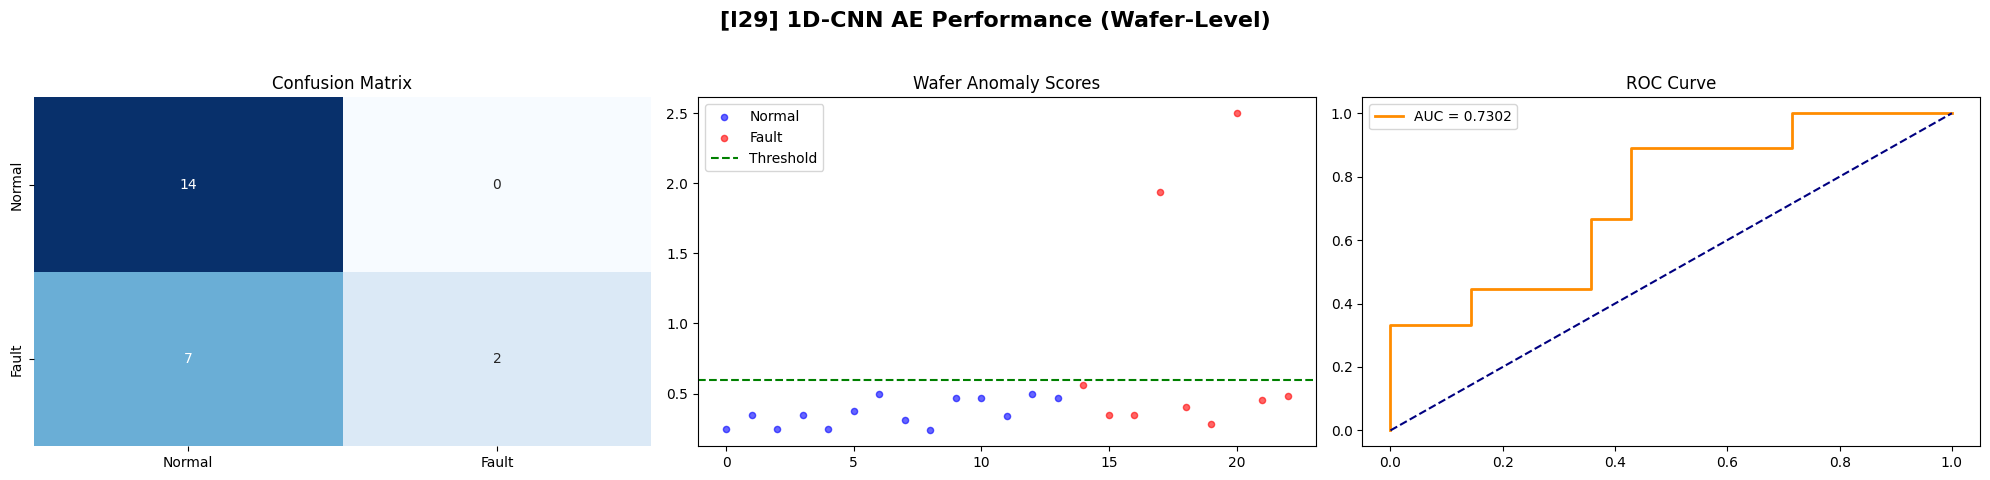


 📊 Evaluating Experiment: l31
Calculating Test Window Scores...
Aggregating Test Wafer Scores...

📏 Calibrated Threshold (from first 10 Test Wafers): 0.280178

📌 [1D-CNN AE - l31] Wafer-Level Summary (Unsupervised)
   - AUROC          : 0.9222
   - F1-Score       : 0.8333 (at Fixed Threshold: 0.280178)


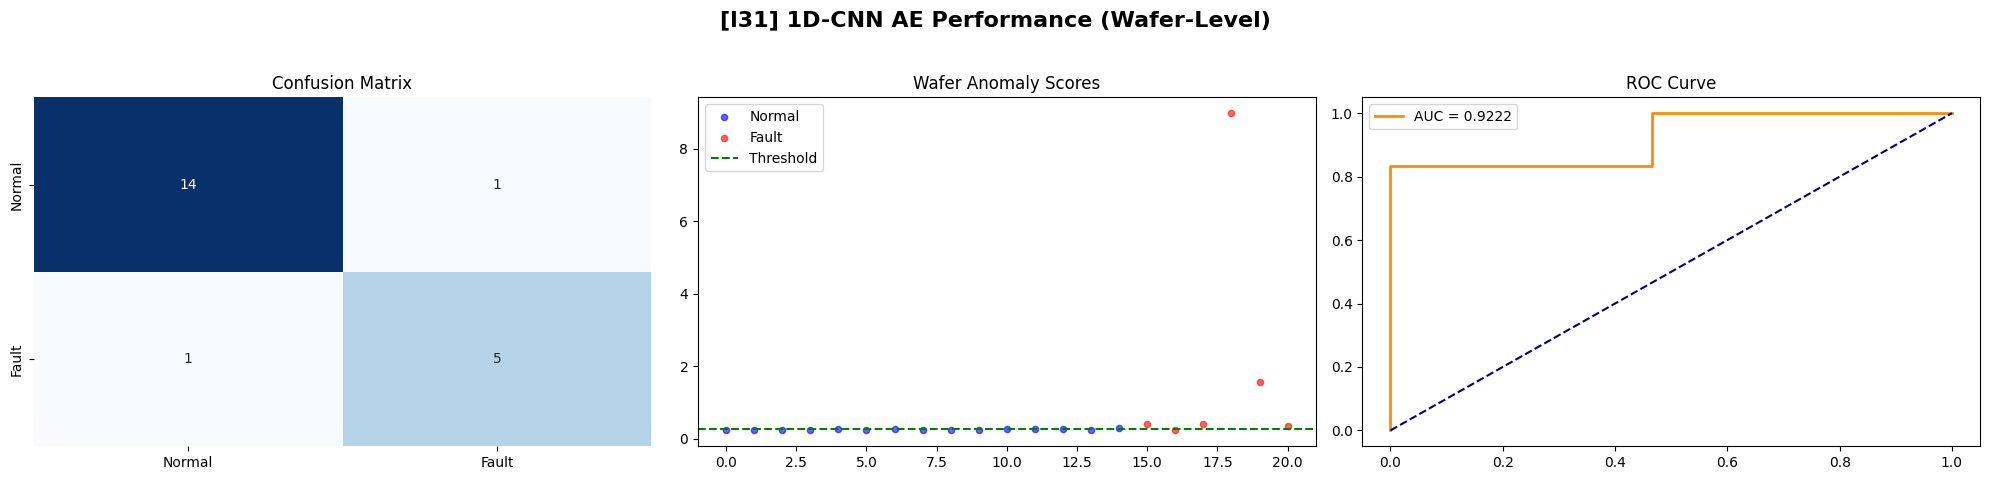


 📊 Evaluating Experiment: l33
Calculating Test Window Scores...
Aggregating Test Wafer Scores...

📏 Calibrated Threshold (from first 10 Test Wafers): 0.413482

📌 [1D-CNN AE - l33] Wafer-Level Summary (Unsupervised)
   - AUROC          : 0.6333
   - F1-Score       : 0.5000 (at Fixed Threshold: 0.413482)


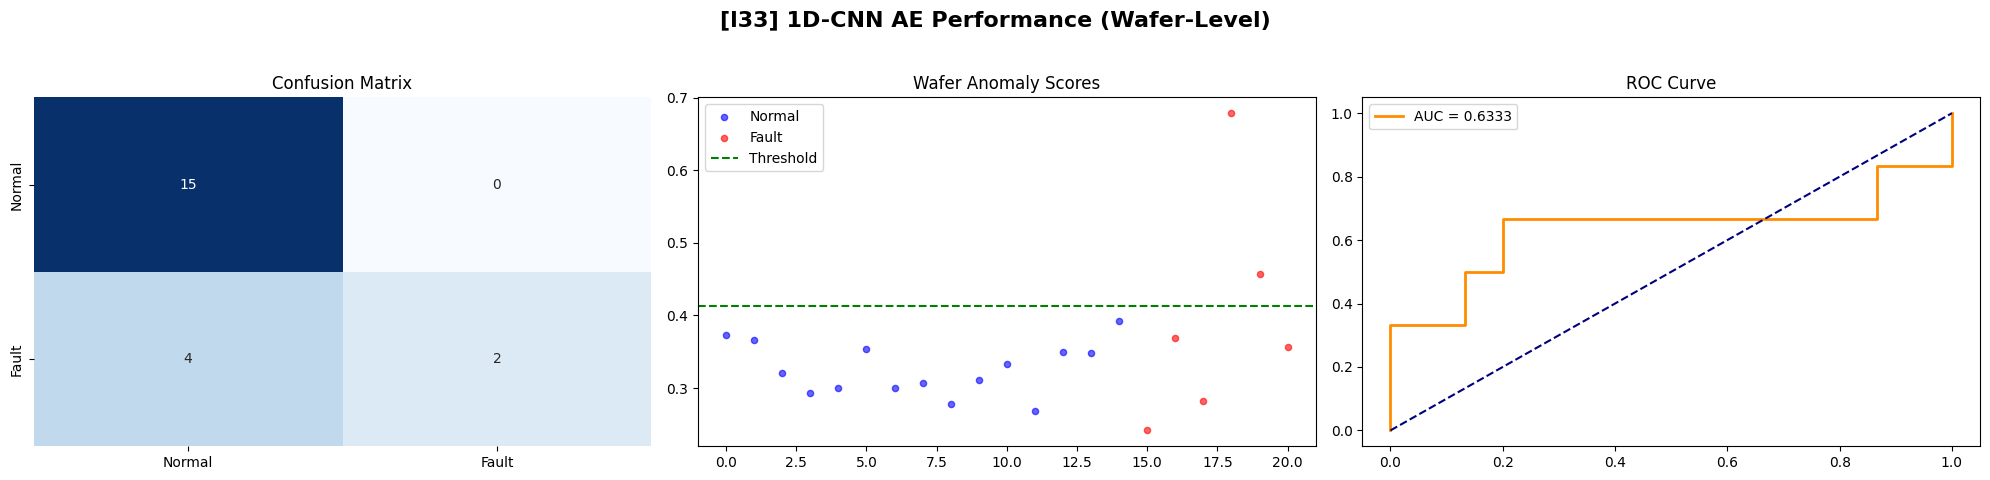

In [12]:
# ==========================================
# 1D-CNN AE 모델 추론 및 시각화 (Phase 2)
# ==========================================

target_experiments = ['l29', 'l31', 'l33']
BATCH_SIZE = 32

# [핵심 수정 포인트] 평가할 모델 이름을 정확히 1D-CNN AE로 지정!
m_name = "1D-CNN AE"

if m_name not in trained_artifacts:
    print(f"❌ Error: Model '{m_name}' is not trained yet.")
else:
    print(f"\n🔍 Phase 2: Evaluating [{m_name}] on Experiments: {target_experiments}")

    for exp_id in target_experiments:
        if exp_id not in trained_artifacts[m_name]:
            print(f"Skipping {exp_id}: No trained model found.")
            continue

        print(f"\n" + "="*50)
        print(f" 📊 Evaluating Experiment: {exp_id}")
        print("="*50)

        saved_model = trained_artifacts[m_name][exp_id]['model']
        fixed_threshold = trained_artifacts[m_name][exp_id]['threshold']

        data = datasets[exp_id]
        test_norm = torch.FloatTensor(data['X_test_norm']).to(device)

        if len(data['X_test_fault']) > 0:
            test_fault = torch.FloatTensor(data['X_test_fault']).to(device)
        else:
            test_fault = torch.FloatTensor([]).to(device)

        ids_norm = data['ids_test_norm']
        ids_fault = data['ids_test_fault']

        print("Calculating Test Window Scores...")
        norm_window_scores = cnn1d_calculate_window_scores(saved_model, test_norm, device, BATCH_SIZE)
        if len(test_fault) > 0:
            fault_window_scores = cnn1d_calculate_window_scores(saved_model, test_fault, device, BATCH_SIZE)
        else:
            fault_window_scores = np.array([])

        print("Aggregating Test Wafer Scores...")
        _, norm_wafer_scores = aggregate_wafer_scores(norm_window_scores, ids_norm, method='max')
        norm_labels = np.zeros(len(norm_wafer_scores))

        if len(fault_window_scores) > 0:
            _, fault_wafer_scores = aggregate_wafer_scores(fault_window_scores, ids_fault, method='max')
            fault_labels = np.ones(len(fault_wafer_scores))
        else:
            fault_wafer_scores = np.array([])
            fault_labels = np.array([])

        final_scores = np.concatenate([norm_wafer_scores, fault_wafer_scores])
        final_labels = np.concatenate([norm_labels, fault_labels])

        CALIBRATION_WINDOW = 10

        if len(norm_wafer_scores) >= CALIBRATION_WINDOW:
            calibration_scores = norm_wafer_scores[:CALIBRATION_WINDOW]
            cal_mean = np.mean(calibration_scores)
            cal_std = np.std(calibration_scores)
            # 보정된 Test 데이터의 평균과 편차를 바탕으로 3-Sigma 적용
            calibrated_threshold = cal_mean + (3 * cal_std)
            print(f"\n📏 Calibrated Threshold (from first {CALIBRATION_WINDOW} Test Wafers): {calibrated_threshold:.6f}")
        else:
            calibrated_threshold = fixed_threshold # 데이터가 부족하면 기존 Train 임계값 사용
            print("\n⚠️ Not enough data for calibration. Using Train-based threshold.")
        # ==========================================

        # 5. 평가 및 시각화 (기존 fixed_threshold 대신 calibrated_threshold 사용)
        if len(np.unique(final_labels)) > 1:
            auc_score, f1 = evaluate_performance_fixed_threshold(
                m_name, exp_id, final_scores, final_labels, calibrated_threshold
            )

## **VTimesNet**


🔍 Phase 2: Evaluating [V-TimesNet] on Experiments: ['l29', 'l31', 'l33']

 📊 Evaluating Experiment: l29
Calculating Test Window Scores...
Aggregating Test Wafer Scores...

📏 Calibrated Threshold (from first 10 Test Wafers): 0.005296

📌 [V-TimesNet - l29] Wafer-Level Summary (Unsupervised)
   - AUROC          : 0.9048
   - F1-Score       : 0.7143 (at Fixed Threshold: 0.005296)


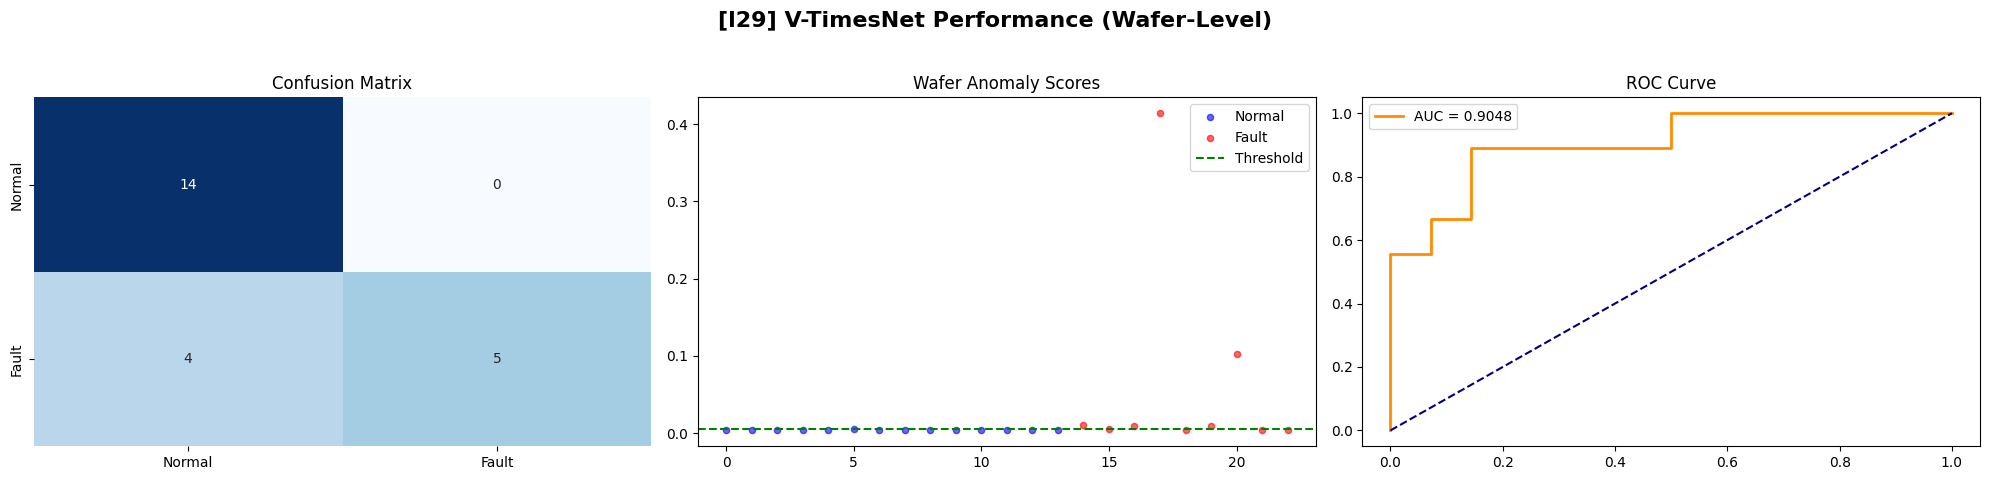


 📊 Evaluating Experiment: l31
Calculating Test Window Scores...
Aggregating Test Wafer Scores...

📏 Calibrated Threshold (from first 10 Test Wafers): 0.004642

📌 [V-TimesNet - l31] Wafer-Level Summary (Unsupervised)
   - AUROC          : 0.9000
   - F1-Score       : 0.8000 (at Fixed Threshold: 0.004642)


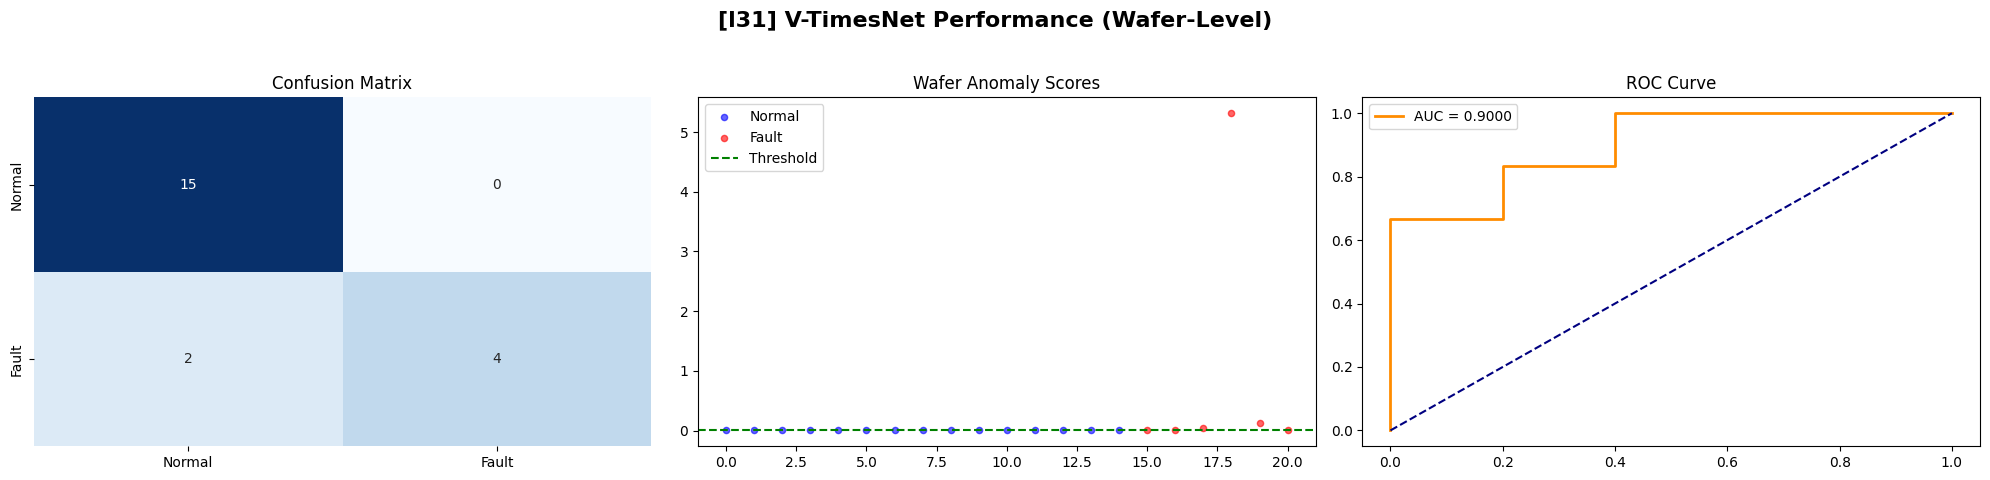


 📊 Evaluating Experiment: l33
Calculating Test Window Scores...
Aggregating Test Wafer Scores...

📏 Calibrated Threshold (from first 10 Test Wafers): 0.007539

📌 [V-TimesNet - l33] Wafer-Level Summary (Unsupervised)
   - AUROC          : 0.9333
   - F1-Score       : 0.6667 (at Fixed Threshold: 0.007539)


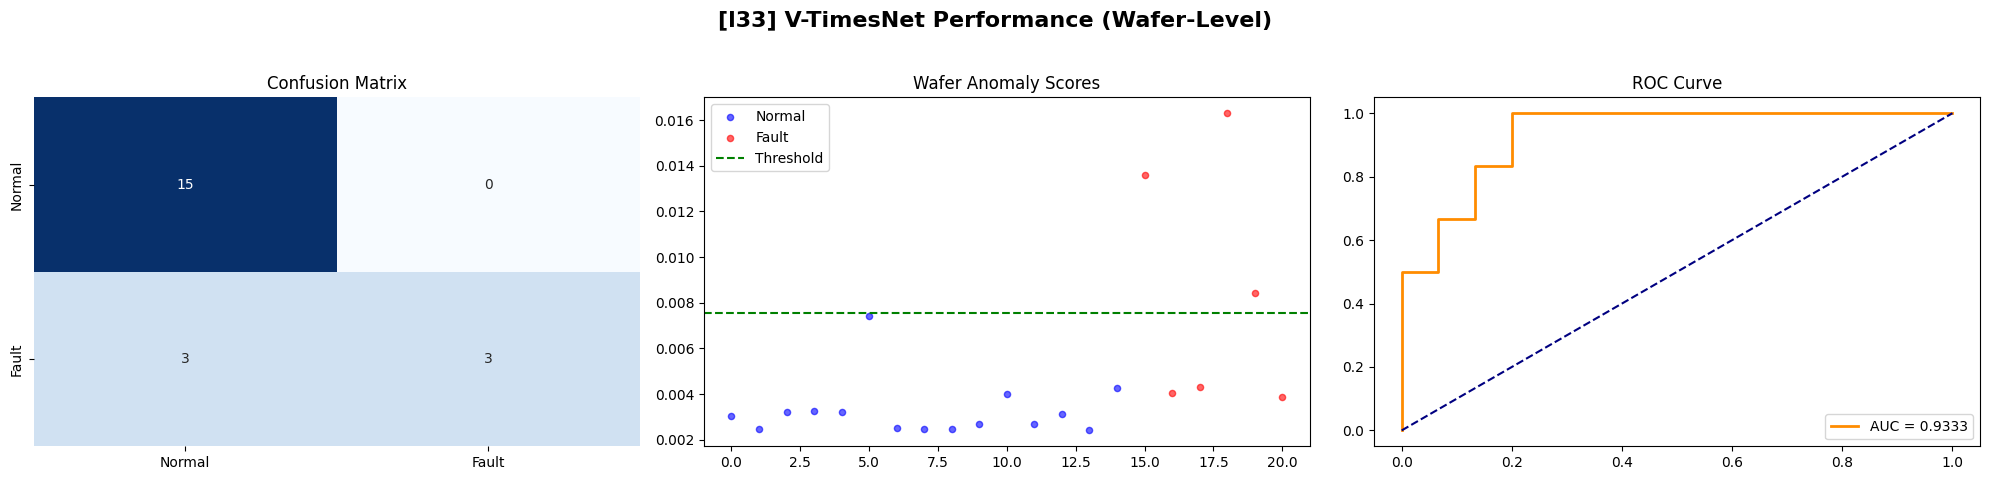

In [13]:
# -----------------------------------------------------------
# VTimesNet 모델 추론 및 시각화 (Phase 2)
# -----------------------------------------------------------
m_name = "V-TimesNet"

if m_name not in trained_artifacts:
    print(f"❌ Error: Model '{m_name}' is not trained yet.")
else:
    print(f"\n🔍 Phase 2: Evaluating [{m_name}] on Experiments: {target_experiments}")

    for exp_id in target_experiments:
        if exp_id not in trained_artifacts[m_name]:
            print(f"Skipping {exp_id}: No trained model found.")
            continue

        print(f"\n" + "="*50)
        print(f" 📊 Evaluating Experiment: {exp_id}")
        print("="*50)

        # 저장된 객체 및 고유 변수 불러오기
        saved_model = trained_artifacts[m_name][exp_id]['model']
        fixed_threshold = trained_artifacts[m_name][exp_id]['threshold']
        config = trained_artifacts[m_name][exp_id]['config']

        # 해당 실험의 Test Data 로드 (GPU OOM 방지를 위해 CPU Tensor로 유지)
        data = datasets[exp_id]
        test_norm = torch.FloatTensor(data['X_test_norm'])

        if len(data['X_test_fault']) > 0:
            test_fault = torch.FloatTensor(data['X_test_fault'])
        else:
            test_fault = torch.FloatTensor([])

        ids_norm = data['ids_test_norm']
        ids_fault = data['ids_test_fault']

        # 추론 수행 (Test Data 전용)
        print("Calculating Test Window Scores...")
        norm_window_scores = vtimesnet_calculate_window_scores(saved_model, test_norm, device, BATCH_SIZE)
        if len(test_fault) > 0:
            fault_window_scores = vtimesnet_calculate_window_scores(saved_model, test_fault, device, BATCH_SIZE)
        else:
            fault_window_scores = np.array([])

        # Wafer 단위 집계
        print("Aggregating Test Wafer Scores...")
        _, norm_wafer_scores = aggregate_wafer_scores(norm_window_scores, ids_norm, method='max')
        norm_labels = np.zeros(len(norm_wafer_scores))

        if len(fault_window_scores) > 0:
            _, fault_wafer_scores = aggregate_wafer_scores(fault_window_scores, ids_fault, method='max')
            fault_labels = np.ones(len(fault_wafer_scores))
        else:
            fault_wafer_scores = np.array([])
            fault_labels = np.array([])

        final_scores = np.concatenate([norm_wafer_scores, fault_wafer_scores])
        final_labels = np.concatenate([norm_labels, fault_labels])

        CALIBRATION_WINDOW = 10

        if len(norm_wafer_scores) >= CALIBRATION_WINDOW:
            calibration_scores = norm_wafer_scores[:CALIBRATION_WINDOW]
            cal_mean = np.mean(calibration_scores)
            cal_std = np.std(calibration_scores)
            # 보정된 Test 데이터의 평균과 편차를 바탕으로 3-Sigma 적용
            calibrated_threshold = cal_mean + (3 * cal_std)
            print(f"\n📏 Calibrated Threshold (from first {CALIBRATION_WINDOW} Test Wafers): {calibrated_threshold:.6f}")
        else:
            calibrated_threshold = fixed_threshold # 데이터가 부족하면 기존 Train 임계값 사용
            print("\n⚠️ Not enough data for calibration. Using Train-based threshold.")
        # ==========================================

        # 5. 평가 및 시각화 (기존 fixed_threshold 대신 calibrated_threshold 사용)
        if len(np.unique(final_labels)) > 1:
            auc_score, f1 = evaluate_performance_fixed_threshold(
                m_name, exp_id, final_scores, final_labels, calibrated_threshold
            )

## **TRACE-GPT**


🔍 Phase 2: Evaluating [TRACE-GPT] on Experiments: ['l29', 'l31', 'l33']

 📊 Evaluating Experiment: l29
Calculating Test Window Scores...
Aggregating Test Wafer Scores...

📏 Calibrated Threshold (from first 10 Test Wafers): 3.542757

📌 [TRACE-GPT - l29] Wafer-Level Summary (Unsupervised)
   - AUROC          : 0.9921
   - F1-Score       : 0.8750 (at Fixed Threshold: 3.542757)


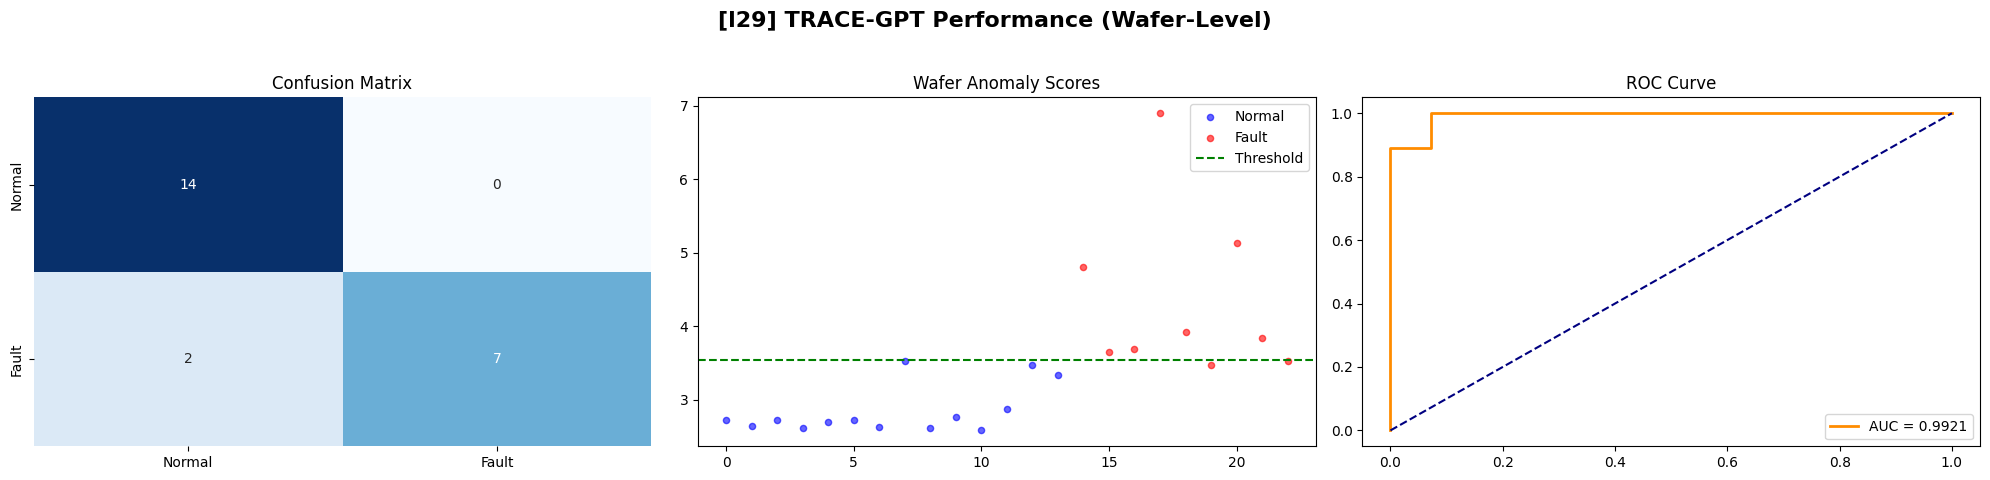


 📊 Evaluating Experiment: l31
Calculating Test Window Scores...
Aggregating Test Wafer Scores...

📏 Calibrated Threshold (from first 10 Test Wafers): 3.221848

📌 [TRACE-GPT - l31] Wafer-Level Summary (Unsupervised)
   - AUROC          : 1.0000
   - F1-Score       : 1.0000 (at Fixed Threshold: 3.221848)


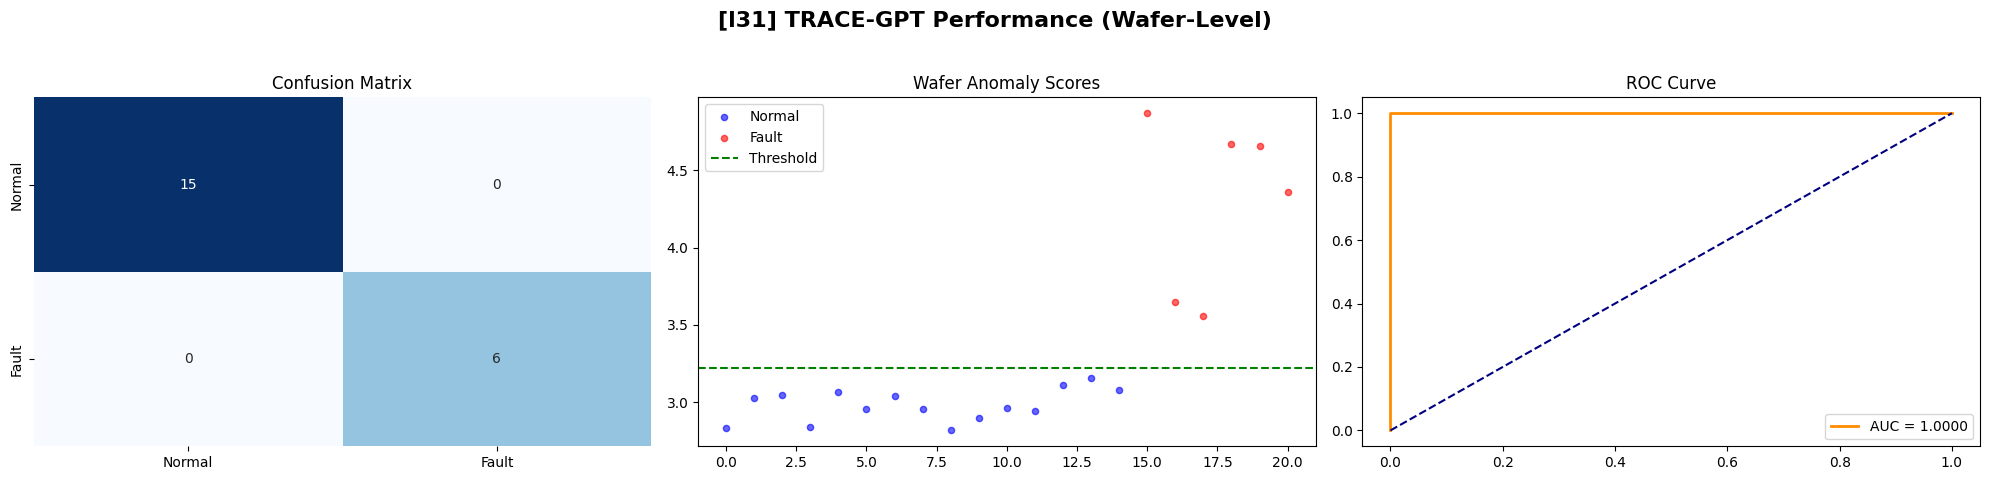


 📊 Evaluating Experiment: l33
Calculating Test Window Scores...
Aggregating Test Wafer Scores...

📏 Calibrated Threshold (from first 10 Test Wafers): 3.157368

📌 [TRACE-GPT - l33] Wafer-Level Summary (Unsupervised)
   - AUROC          : 1.0000
   - F1-Score       : 0.9231 (at Fixed Threshold: 3.157368)


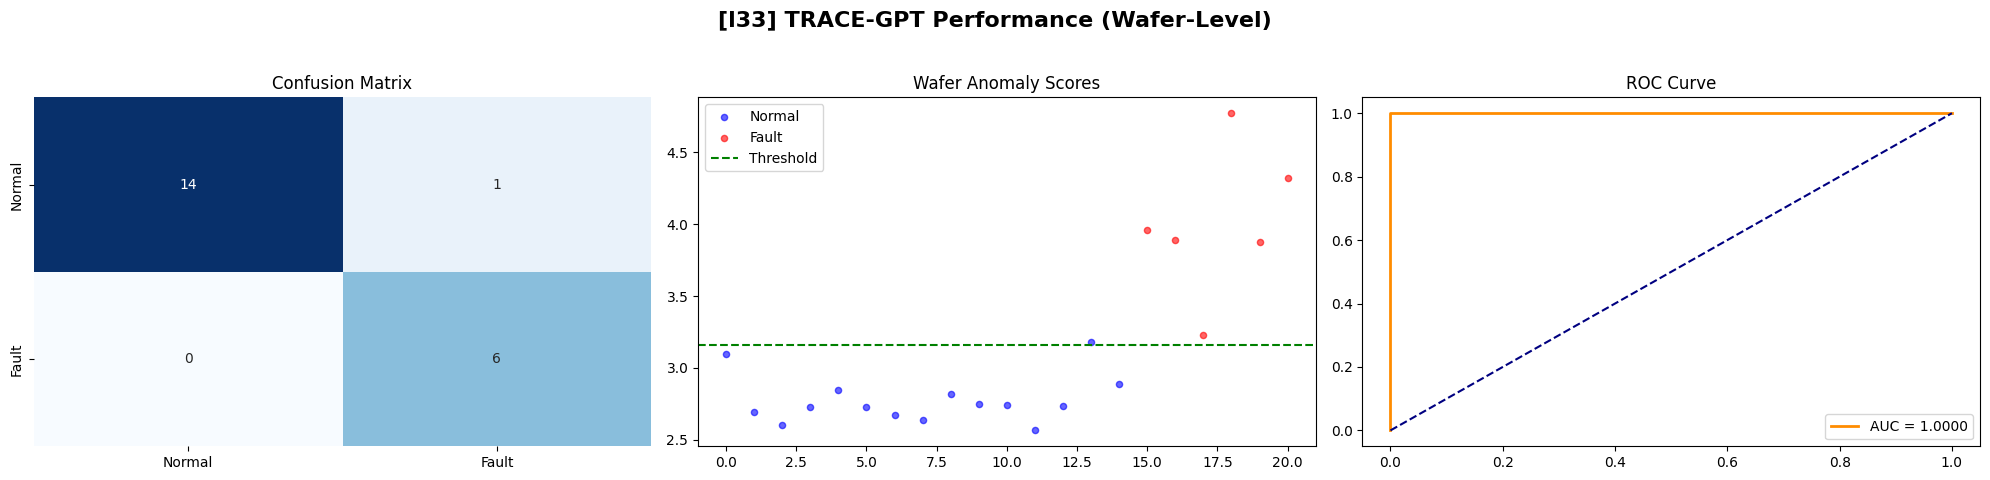

In [14]:
# ==========================================
# 실험별 모델 추론 및 시각화
# ==========================================
target_experiments = ['l29', 'l31', 'l33']
BATCH_SIZE = 32

m_name = "TRACE-GPT"

if m_name not in trained_artifacts:
    print(f"❌ Error: Model '{m_name}' is not trained yet.")
else:
    print(f"\n🔍 Phase 2: Evaluating [{m_name}] on Experiments: {target_experiments}")

    for exp_id in target_experiments:
        if exp_id not in trained_artifacts[m_name]:
            print(f"Skipping {exp_id}: No trained model found.")
            continue

        print(f"\n" + "="*50)
        print(f" 📊 Evaluating Experiment: {exp_id}")
        print("="*50)

        # 저장된 객체 및 고유 변수 불러오기
        saved_model = trained_artifacts[m_name][exp_id]['model']
        fixed_threshold = trained_artifacts[m_name][exp_id]['threshold']
        config = trained_artifacts[m_name][exp_id]['config']

        # 해당 실험의 Test Data 로드
        data = datasets[exp_id]
        test_norm = torch.FloatTensor(data['X_test_norm']).to(device)

        if len(data['X_test_fault']) > 0:
            test_fault = torch.FloatTensor(data['X_test_fault']).to(device)
        else:
            test_fault = torch.FloatTensor([]).to(device)

        ids_norm = data['ids_test_norm']
        ids_fault = data['ids_test_fault']

        # 추론 수행 (Test Data 전용)
        print("Calculating Test Window Scores...")
        norm_window_scores = trace_calculate_window_scores(saved_model, test_norm, device, BATCH_SIZE, config["resolution"])
        if len(test_fault) > 0:
            fault_window_scores = trace_calculate_window_scores(saved_model, test_fault, device, BATCH_SIZE, config["resolution"])
        else:
            fault_window_scores = np.array([])

        # Wafer 단위 집계
        print("Aggregating Test Wafer Scores...")
        _, norm_wafer_scores = aggregate_wafer_scores(norm_window_scores, ids_norm, method='max')
        norm_labels = np.zeros(len(norm_wafer_scores))

        if len(fault_window_scores) > 0:
            _, fault_wafer_scores = aggregate_wafer_scores(fault_window_scores, ids_fault, method='max')
            fault_labels = np.ones(len(fault_wafer_scores))
        else:
            fault_wafer_scores = np.array([])
            fault_labels = np.array([])

        final_scores = np.concatenate([norm_wafer_scores, fault_wafer_scores])
        final_labels = np.concatenate([norm_labels, fault_labels])

        CALIBRATION_WINDOW = 10

        if len(norm_wafer_scores) >= CALIBRATION_WINDOW:
            calibration_scores = norm_wafer_scores[:CALIBRATION_WINDOW]
            cal_mean = np.mean(calibration_scores)
            cal_std = np.std(calibration_scores)
            # 보정된 Test 데이터의 평균과 편차를 바탕으로 3-Sigma 적용
            calibrated_threshold = cal_mean + (3 * cal_std)
            print(f"\n📏 Calibrated Threshold (from first {CALIBRATION_WINDOW} Test Wafers): {calibrated_threshold:.6f}")
        else:
            calibrated_threshold = fixed_threshold # 데이터가 부족하면 기존 Train 임계값 사용
            print("\n⚠️ Not enough data for calibration. Using Train-based threshold.")
        # ==========================================

        # 5. 평가 및 시각화 (기존 fixed_threshold 대신 calibrated_threshold 사용)
        if len(np.unique(final_labels)) > 1:
            auc_score, f1 = evaluate_performance_fixed_threshold(
                m_name, exp_id, final_scores, final_labels, calibrated_threshold
            )